# DINOv2/v3 密集与稀疏匹配 - CPU 测试版

本 notebook 演示如何使用 DINO 特征在两张图片之间建立对应关系。

**关于模型访问：**
- **DINOv2**: 公开可用，无需申请（本 notebook 使用）
- **DINOv3**: 需要申请权限 → [申请地址](https://ai.meta.com/resources/models-and-libraries/dinov3-downloads/)

**适用环境：**
- AMD Ryzen CPU (无 CUDA)
- 32GB 内存

**学习目标：**
1. 理解如何提取图像的 patch 特征
2. 使用余弦相似度进行图像匹配
3. PCA 可视化密集对应关系

## 1. 环境配置

In [4]:
import os
import urllib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib.patches import ConnectionPatch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from tqdm import tqdm

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from transformers import AutoModel, AutoImageProcessor

print(f"PyTorch 版本: {torch.__version__}")
print(f"使用设备: CPU")

PyTorch 版本: 2.10.0+cpu
使用设备: CPU


## 2. 加载模型

我们使用 ViT-S/Small 模型，适合 CPU 推理。

In [5]:
# 使用 Hugging Face DINOv2 (公开可用)
HF_MODEL = 'facebook/dinov2-small'

print(f"正在加载模型: {HF_MODEL}")
print("(首次下载约 80MB，请耐心等待)")

processor = AutoImageProcessor.from_pretrained(HF_MODEL)
model = AutoModel.from_pretrained(HF_MODEL)
model.eval()

# 模型参数
total_params = sum(p.numel() for p in model.parameters())
FEATURE_DIM = 384  # ViT-S/Small 特征维度
PATCH_SIZE = 16

print(f"\n✓ 模型加载完成!")
print(f"  参数量: {total_params / 1e6:.1f}M")
print(f"  特征维度: {FEATURE_DIM}")
print(f"  Patch 大小: {PATCH_SIZE}")

正在加载模型: facebook/dinov2-small
(首次下载约 80MB，请耐心等待)

✓ 模型加载完成!
  参数量: 22.1M
  特征维度: 384
  Patch 大小: 16


## 3. 加载数据

加载两张图片和对应的前景遮罩。

In [6]:
image_left_uri = r"D:\AI\Git\dinov3.git\notebooks\image_left.jpg"
mask_left_uri = r"D:\AI\Git\dinov3.git\notebooks\image_left_fg.png"
image_right_uri = r"D:\AI\Git\dinov3.git\notebooks\image_right.jpg"
mask_right_uri = r"D:\AI\Git\dinov3.git\notebooks\image_right_fg.png"

def load_image_from_url(url: str) -> Image.Image:
    with urllib.request.urlopen(url) as f:
        return Image.open(f)

def load_image_from_path(path: str) -> Image.Image:
    """从本地路径加载图片"""
    return Image.open(path)

print("正在加载图片...")
image_left = load_image_from_path(image_left_uri)
mask_left = load_image_from_path(mask_left_uri)
image_right = load_image_from_path(image_right_uri)
mask_right = load_image_from_path(mask_right_uri)

print(f"✓ 左图尺寸: {image_left.size}")
print(f"✓ 右图尺寸: {image_right.size}")

正在加载图片...
✓ 左图尺寸: (2272, 2141)
✓ 右图尺寸: (4032, 3024)


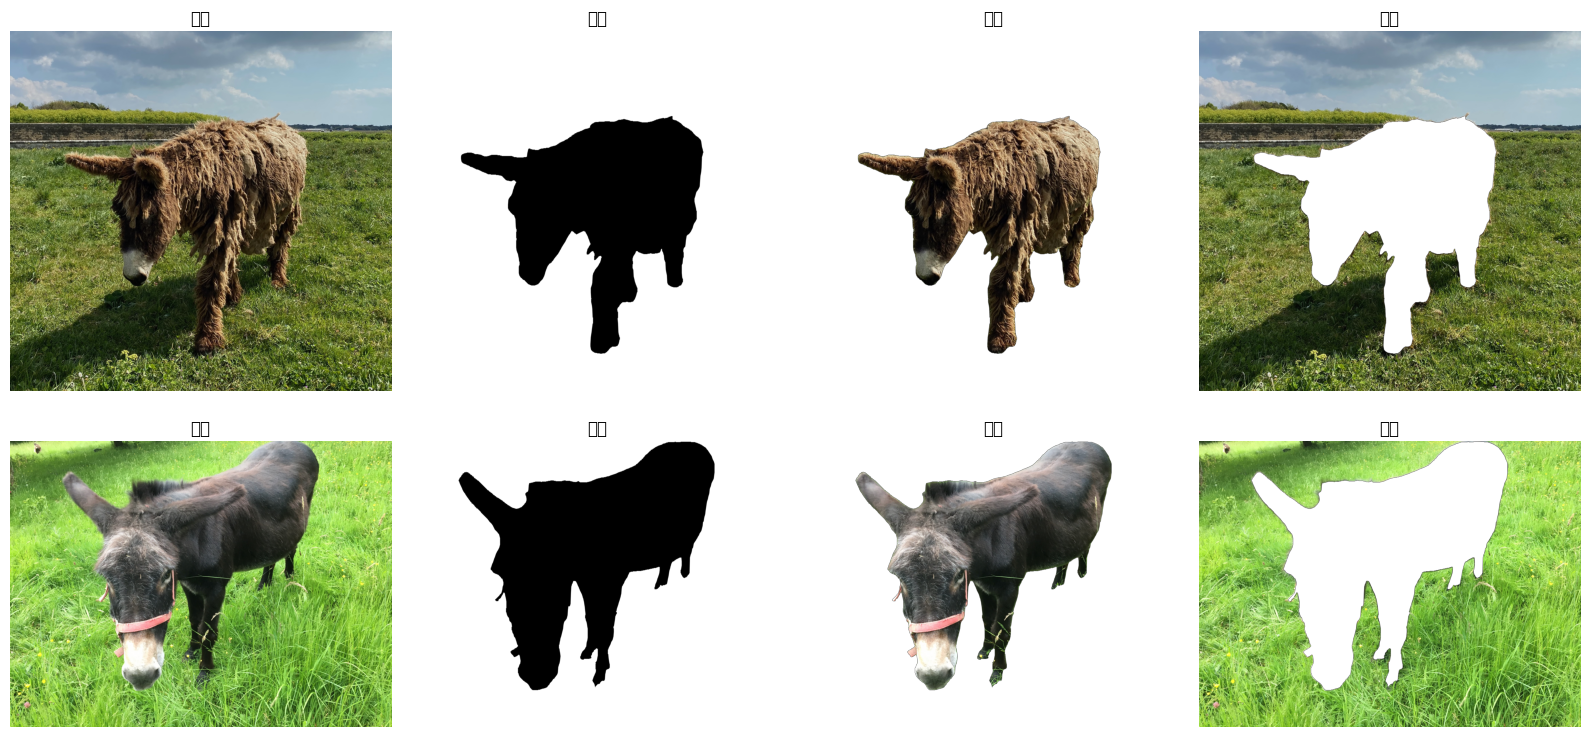

In [7]:
# 可视化
plt.figure(figsize=(16, 8))

for j, (image, mask) in enumerate([(image_left, mask_left), (image_right, mask_right)]):
    foreground = Image.composite(image, mask, mask)
    mask_bg_np = np.copy(np.array(mask))
    mask_bg_np[:, :, 3] = 255 - mask_bg_np[:, :, 3]
    mask_bg = Image.fromarray(mask_bg_np)
    background = Image.composite(image, mask_bg, mask_bg)

    data_to_show = [image, mask, foreground, background]
    data_labels = ["图像", "遮罩", "前景", "背景"]

    for i in range(len(data_to_show)):
        plt.subplot(2, len(data_to_show), 4 * j + i + 1)
        plt.imshow(data_to_show[i])
        plt.axis('off')
        plt.title(data_labels[i])

plt.tight_layout()
plt.show()

## 4. 图像变换

设置图像预处理和遮罩量化。

In [8]:
# 测试获取实际输出大小
test_img = Image.new('RGB', (256, 256))
test_inputs = processor(images=test_img, return_tensors='pt')
with torch.inference_mode():
    test_output = model(**test_inputs)
    ACTUAL_PATCHES = test_output.last_hidden_state.shape[1] - 1

PATCHES_PER_SIDE = int(ACTUAL_PATCHES ** 0.5)
IMAGE_SIZE = PATCHES_PER_SIDE * PATCH_SIZE

print(f"模型实际输出: {ACTUAL_PATCHES} patches ({PATCHES_PER_SIDE}x{PATCHES_PER_SIDE})")
print(f"对应图像大小: {IMAGE_SIZE}x{IMAGE_SIZE}")

# 量化滤波器
patch_quant_filter = torch.nn.Conv2d(1, 1, PATCH_SIZE, stride=PATCH_SIZE, bias=False)
patch_quant_filter.weight.data.fill_(1.0 / (PATCH_SIZE * PATCH_SIZE))

def resize_transform(image, image_size=IMAGE_SIZE):
    """调整图像到固定大小"""
    return TF.to_tensor(TF.resize(image, (image_size, image_size)))

模型实际输出: 256 patches (16x16)
对应图像大小: 256x256


## 5. 提取特征

提取两张图片的 patch 特征和遮罩值。

In [9]:
def extract_features_hf(image_pil):
    """使用 Hugging Face 模型提取特征"""
    inputs = processor(images=image_pil, return_tensors='pt')
    with torch.inference_mode():
        outputs = model(**inputs)
        patch_features = outputs.last_hidden_state[:, 1:, :]
        return patch_features.squeeze(0)  # [num_patches, dim]

patch_mask_values = []
patch_features = []

print("提取特征中...")
for image, mask in tqdm([(image_left, mask_left), (image_right, mask_right)], desc="处理图像"):
    # 处理遮罩
    mask_gray = mask.split()[-1]  # 提取 alpha 通道
    mask_resized = resize_transform(mask_gray)
    mask_quantized = patch_quant_filter(mask_resized).squeeze()
    patch_mask_values.append(mask_quantized)
    
    # 处理图像
    image_rgb = image.convert('RGB')
    features = extract_features_hf(image_rgb)
    patch_features.append(features)

print(f"\n特征形状: {patch_features[0].shape}")
print(f"遮罩形状: {patch_mask_values[0].shape}")

提取特征中...


处理图像: 100%|██████████| 2/2 [00:00<00:00,  5.89it/s]


特征形状: torch.Size([256, 384])
遮罩形状: torch.Size([16, 16])


## 6. 匹配 Patch

对于左图中的每个前景 patch，使用余弦相似度在右图中搜索最相似的 patch。

In [10]:
MASK_FG_THRESHOLD = 0.5

# L2 归一化特征
patch_features[0] = F.normalize(patch_features[0], p=2, dim=1)
patch_features[1] = F.normalize(patch_features[1], p=2, dim=1)

# 计算余弦相似度热图
heatmaps = torch.einsum(
    "kd,dhw->khw",
    patch_features[0],
    patch_features[1].permute(1, 0).view(FEATURE_DIM, PATCHES_PER_SIDE, PATCHES_PER_SIDE)
)

# 左图中 patch 的 2D 位置
n_patches = PATCHES_PER_SIDE * PATCHES_PER_SIDE
patch_indices_left = torch.arange(n_patches)
locs_2d_left = (
    torch.stack(
        (
            patch_indices_left // PATCHES_PER_SIDE,  # row
            patch_indices_left % PATCHES_PER_SIDE    # column
        ),
        dim=-1
    ) + 0.5
) * PATCH_SIZE

# 右图中对应 patch 的 2D 位置
patch_indices_right = torch.flatten(heatmaps, start_dim=-2).argmax(dim=-1)
locs_2d_right = (
    torch.stack(
        (
            patch_indices_right // PATCHES_PER_SIDE,  # row
            patch_indices_right % PATCHES_PER_SIDE    # column
        ),
        dim=-1
    ) + 0.5
) * PATCH_SIZE

# 前景选择
patches_left_fg_selection = (patch_mask_values[0].view(-1) > MASK_FG_THRESHOLD)
patches_right_fg_selection = (patch_mask_values[1].view(-1)[patch_indices_right] > MASK_FG_THRESHOLD)
patches_fg_selection = (patches_left_fg_selection * patches_right_fg_selection)

# 选择匹配的坐标
locs_2d_left_fg = locs_2d_left[patches_fg_selection, :]
locs_2d_right_fg = locs_2d_right[patches_fg_selection, :]

print(f"匹配的前景 patch 数量: {locs_2d_left_fg.shape[0]}")

匹配的前景 patch 数量: 40


## 7. 密集对应关系

使用 PCA 可视化密集对应关系，相似颜色表示相似的 patch。

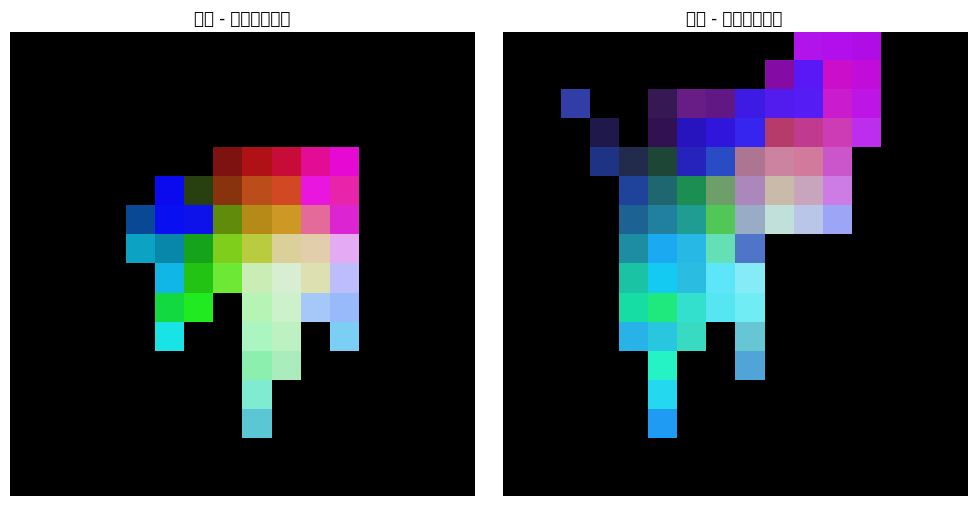

In [11]:
# PCA 降维
pca = PCA(n_components=3, whiten=True)
fg_patches_left = patch_features[0][patches_fg_selection]
pca.fit(fg_patches_left.numpy())

# 左图颜色
x_left = patch_features[0].numpy()
projected_left = pca.transform(x_left).reshape(PATCHES_PER_SIDE, PATCHES_PER_SIDE, 3)
projected_left = torch.nn.functional.sigmoid(torch.from_numpy(projected_left).float().mul(2.0))
projected_left = projected_left.permute(2, 0, 1)

# 右图颜色
x_right = patch_features[1].numpy()
projected_right = pca.transform(x_right).reshape(PATCHES_PER_SIDE, PATCHES_PER_SIDE, 3)
projected_right = torch.nn.functional.sigmoid(torch.from_numpy(projected_right).float().mul(2.0))
projected_right = projected_right.permute(2, 0, 1)

# 应用前景遮罩
projected_left *= (patch_mask_values[0] > MASK_FG_THRESHOLD)[None, :, :]
projected_right *= (patch_mask_values[1] > MASK_FG_THRESHOLD)[None, :, :]

# 可视化
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(projected_left.permute(1, 2, 0))
plt.title("左图 - 密集对应关系")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(projected_right.permute(1, 2, 0))
plt.title("右图 - 密集对应关系")
plt.axis('off')
plt.tight_layout()
plt.show()

## 8. 稀疏对应关系

显示匹配点之间的连线。

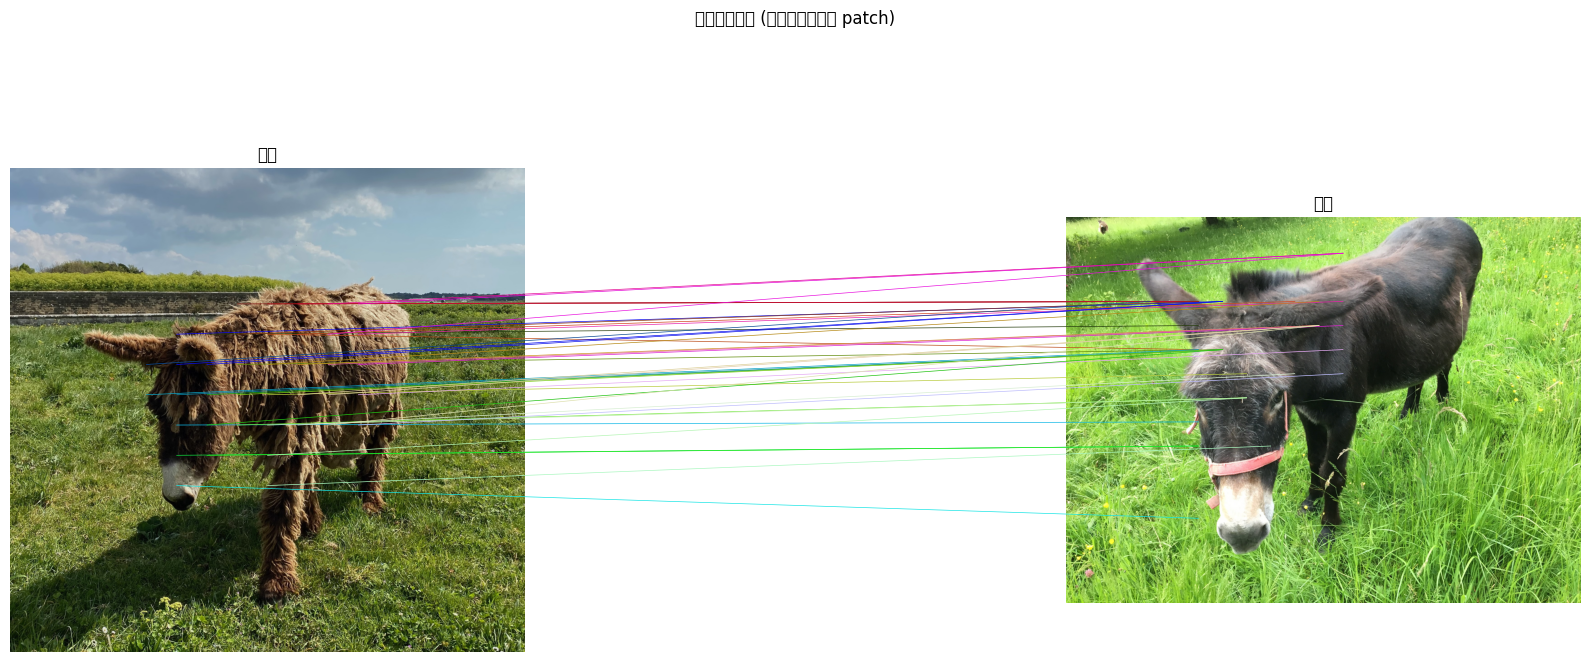

In [12]:
# 图像缩放比例
scale_left = image_left.height / IMAGE_SIZE
scale_right = image_right.height / IMAGE_SIZE

# 采样部分点以便可视化
n_points = min(50, len(locs_2d_left_fg))
sample_indices = np.linspace(0, len(locs_2d_left_fg) - 1, n_points, dtype=int)

sparse_points_left = locs_2d_left_fg[sample_indices].numpy()
sparse_points_right = locs_2d_right_fg[sample_indices].numpy()

# 可视化
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(121)
ax1.imshow(image_left)
ax1.set_title("左图")
ax1.axis('off')

ax2 = fig.add_subplot(122)
ax2.imshow(image_right)
ax2.set_title("右图")
ax2.axis('off')

# 绘制连线
for i, (row_left, col_left), (row_right, col_right) in zip(
    sample_indices, sparse_points_left, sparse_points_right
):
    # 使用 PCA 颜色
    color = projected_left[
        :,
        int(row_left / PATCH_SIZE),
        int(col_left / PATCH_SIZE)
    ].numpy()
    
    con = ConnectionPatch(
        xyA=(col_left * scale_left, row_left * scale_left),
        xyB=(col_right * scale_right, row_right * scale_right),
        coordsA="data",
        coordsB="data",
        axesA=ax1,
        axesB=ax2,
        color=color,
        linewidth=0.5,
    )
    ax2.add_artist(con)

plt.suptitle("稀疏对应关系 (连线连接匹配的 patch)")
plt.tight_layout()
plt.show()

## 总结

恭喜！你已经成功实现了图像匹配！

**关键学习点：**
1. DINO 特征具有良好的语义相似性
2. 余弦相似度可用于衡量 patch 之间的匹配程度
3. PCA 可视化能直观展示密集对应关系

**下一步学习：**
1. 尝试不同的图片对
2. 调整 `MASK_FG_THRESHOLD` 观察效果
3. 学习 `segmentation_tracking.ipynb` - 视频分割跟踪